# Find the darkest image in a folder
## *Buscar la imagen más oscura en una carpeta*

Project workflow / *Flujo de trabajo del proyecto*

| # | EN | ES |
|---|---------|---------|
| 1 | Get an image from the folder | Obtener una imagen de la carpeta |
| 2 | Compute the mean gray value (or the V channel in HSV) | Calcular el promedio de grises (o el valor V en HSV) |
| 3 | Sort the dictionary by value | Ordenar el diccionario por valor |

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gc

## Configuration of Variables and functions
### *Configuración de variables y funciones*

In [7]:
imgFilePath = "/mnt/datos_compartidos/PortafolioProyectos/imgsPruebas"

top = 15

In [8]:
def getMean(imgPath, useHSV = False):  # Define function to compute mean brightness of an image / Definir función para calcular el brillo medio de una imagen
    img = cv2.imread(imgPath)  # Read image from path with OpenCV / Leer imagen desde la ruta con OpenCV
    if img is None:  # If image could not be read / Si la imagen no se pudo leer
        return None  # Return None / Devolver None
    if useHSV:  # If HSV mode is requested / Si se solicita modo HSV
        imgMod = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)  # Convert BGR to HSV / Convertir BGR a HSV
        imgMod = imgMod[:,:,2]  # Extract V channel (brightness) / Extraer canal V (brillo)
    else:  # Otherwise use grayscale / En caso contrario usar escala de grises
        imgMod = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert BGR to grayscale / Convertir BGR a escala de grises

    return np.mean(imgMod)  # Return mean value / Devolver valor medio

def showImg(imgPath, showHist = False):  # Define function to display an image and optionally its brightness histogram / Definir función para mostrar una imagen y opcionalmente su histograma de brillo

    img = cv2.imread(imgPath)  # Read image from path / Leer imagen desde la ruta
    imgHSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)  # Convert BGR to HSV / Convertir BGR a HSV
    light = imgHSV[:,:,2]  # Extract V channel (brightness) / Extraer canal V (brillo)
    
    plt.figure(figsize=(12, 4))  # Create figure with size 12x4 / Crear figura con tamaño 12x4
    if showHist:  # If histogram display is enabled / Si mostrar histograma está habilitado
        plt.subplot(1,2,1)  # Create first subplot (1 row, 2 cols, pos 1) / Crear primer subplot (1 fila, 2 cols, pos 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Display image converted BGR to RGB / Mostrar imagen convertida de BGR a RGB
    plt.title(f"{Path(imgPath).name}")  # Set title with image filename / Establecer título con nombre del archivo
    plt.axis('off')  # Hide axes / Ocultar ejes

    if showHist:  # If histogram display is enabled / Si mostrar histograma está habilitado
        plt.subplot(1, 2, 2)  # Create second subplot (1 row, 2 cols, pos 2) / Crear segundo subplot (1 fila, 2 cols, pos 2)
        plt.hist(light.ravel(), bins=256, range=[0, 256], alpha=0.7, color='gray')  # Plot histogram of brightness values / Graficar histograma de valores de brillo
        plt.axvline(light.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {light.mean():.2f}')  # Draw vertical line at mean brightness / Dibujar línea vertical en el brillo medio
        plt.title('Histogram')  # Set histogram title / Establecer título del histograma
        plt.xlabel('Light value')  # Set X-axis label / Establecer etiqueta del eje X
        plt.ylabel('Frequency')  # Set Y-axis label / Establecer etiqueta del eje Y
        plt.legend()  # Show legend / Mostrar leyenda
    plt.tight_layout()  # Adjust layout / Ajustar diseño
    plt.show()  # Show figure / Mostrar figura

## Code
### *Código*

In [9]:
extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}  # Supported image extensions / Extensiones de imagen soportadas
    
results = []  # Initialize list to store results / Inicializar lista para almacenar resultados
    
for file in Path(imgFilePath).iterdir():  # Iterate over files in the given folder / Iterar sobre archivos en la carpeta dada
    if file.suffix.lower() in extensions:  # Check if file extension is supported / Verificar si la extensión del archivo es soportada
        path = str(file)  # Convert Path object to string / Convertir objeto Path a cadena
        lightValue = getMean(path, useHSV=False)  # Compute mean brightness (grayscale) / Calcular brillo medio (escala de grises)
            
        if lightValue is not None:  # If brightness could be computed / Si se pudo calcular el brillo
            results.append({  # Append result dict / Agregar dict de resultado
                'file': file.name,  # Store filename / Almacenar nombre de archivo
                'path': path,  # Store full path / Almacenar ruta completa
                'light': lightValue  # Store brightness value / Almacenar valor de brillo
            })

results = sorted(results, key=lambda x: x['light'])  # Sort results by brightness ascending / Ordenar resultados por brillo ascendente

del extensions, path, lightValue  # Delete intermediate variables / Eliminar variables intermedias
gc.collect()  # Force garbage collector to free memory / Forzar recolector de basura para liberar memoria

0

1. image4.png - 14.84
2. image0.png - 15.94
3. image7.jpg - 17.48
4. image3.png - 27.23
5. image1.png - 31.29
6. image2.png - 32.12
7. image6.png - 37.47
8. image5.png - 53.45
9. image8.png - 129.24


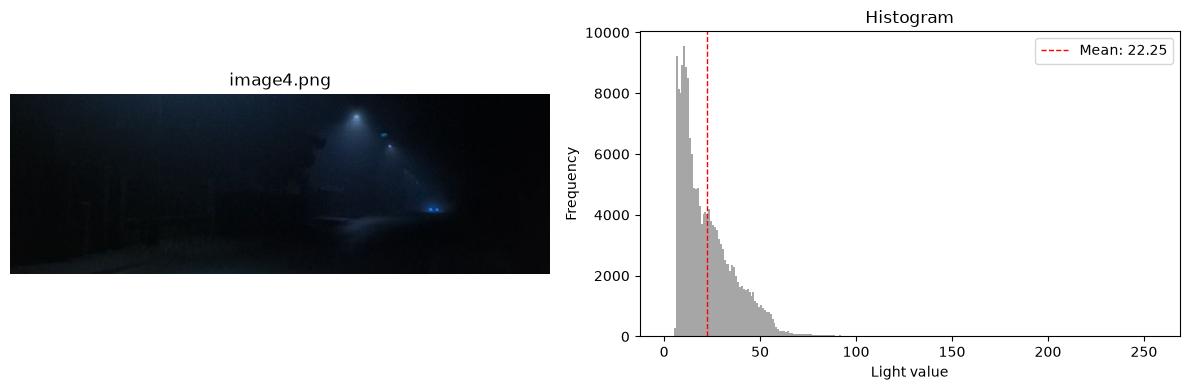

In [10]:
for i, result in enumerate(results[:top]):
    print(f"{i+1}. {result['file']} - {result['light']:.2f}")


showImg(results[0]['path'], showHist=True)